#  TASK-03

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('loan_default.csv')
X = df[['Income']]
y = df['LoanAmount']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.277e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [4]:
print('Slope:', model.coef_)
print('Intercept:', model.intercept_)
print('Prediction for Income 40000:', model.predict([[40000]]))

Slope: [-0.00157329]
Intercept: 127708.66118348073
Prediction for Income 40000: [127645.72941857]


D:\B.E DU\SEM - 5\ML\Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
X_raw = df[['Income']].values
Y = df['LoanAmount'].values.astype(float).flatten()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).flatten()
n = len(Y)
m, c = 0.0, 0.0
lr = 0.05
epochs = 1000
loss_history = []

for i in range(epochs):
    Y_pred = m * X_scaled + c
    error = Y_pred - Y

    loss = (1 / n) * np.sum(error ** 2)
    loss_history.append(loss)
    dm = (2 / n) * np.sum(error * X_scaled)
    dc = (2 / n) * np.sum(error)

    m -= lr * dm
    c -= lr * dc

    if i % 200 == 0:
        print(f"Epoch {i:4d} | Loss: {loss:.2f} | m: {m:.4f} | c: {c:.2f}")

Epoch    0 | Loss: 21294752918.78 | m: -6.1300 | c: 12757.89
Epoch  200 | Loss: 5018382235.64 | m: -61.3002 | c: 127578.87
Epoch  400 | Loss: 5018382235.64 | m: -61.3002 | c: 127578.87
Epoch  600 | Loss: 5018382235.64 | m: -61.3002 | c: 127578.87
Epoch  800 | Loss: 5018382235.64 | m: -61.3002 | c: 127578.87


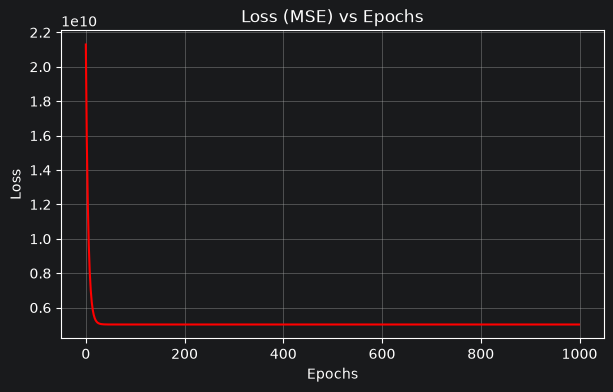

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='red')
plt.title('Loss (MSE) vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()